In [ ]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
import scipy.constants as c
from scipy.optimize import curve_fit
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.integrate import quad
from scipy.signal import find_peaks,peak_widths
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial

%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path
from pathlib import Path

import pandas as pd # Auch wichtig für den Latex Export
from pytexit import py2tex
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

# Grafiken in EU-Größen ausgeben
def figsize_cm(width_cm, height_cm):
    return (2*width_cm / 2.54, 2*height_cm / 2.54)
def comma_to_float(valstr):
    return float(valstr.replace(',','.'))

In [2]:
currentversuch = "211"
base = Path.cwd()                   
Messwerte_path = Path(base.parent.parent.parent/"Messwerte"/currentversuch)      # initializing paths
Ausgabe_path = Path(base/"Diagramme")
print(Messwerte_path)
print(Ausgabe_path)



c:\Users\samue\OneDrive\Dokumente\PAP\PAP2.1\Messwerte\211
c:\Users\samue\OneDrive\Dokumente\PAP\PAP2.1\Auswertungen\Code\211\Diagramme


Runden signifikanter Stellen

In [3]:
def round_sig_digs(val, errVal):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
    ----------
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
    ------
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """

    # Daten zu Dezimal wechseln, da Floats probleme machen
    val = Decimal(str(val))
    errVal = Decimal(str(errVal))

    exp = int(math.floor(math.log10(float(errVal))))            # Die erste signifikante Stellenposition wird anhand des errVal bestimmt

    if round(float(errVal / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1

    scale = Decimal(10) ** exp                                  

    val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale            # mit scale wird das Komma so verschoben, dass alle signifikanten Stellen vor dem Komma stehen, und dann alle Nachkommastellen weggerundet werden
    err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale

    res = f"\\num{{{val_round}({err_round})}}"
    return float(val_round), float(err_round), res

    # wissenschaftliche Notation erstmal vernachlässigen (da häufig Einheiten gewollt sind, die 10^/e Prefixe beinhalten)

Gausssche Fehlerfortpflanzung

In [4]:
def gff(function, errPronePar):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
    ----------
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
    ----------
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamaters = []

    function = sp.sympify(function)
    variables = errPronePar.split(",")
    variables = sp.symbols(variables)

    for variable in variables:
        Delta = sp.Symbol(f"Delta_{variable}")
        partial = sp.diff(function, variable)                   # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        term=sp.UnevaluatedExpr(partial*Delta)**2
        error = error + ((term))                                # Fehler werden quadratisch aufsummiert
        errProneParamaters.append((variable,Delta))
    latex_absolute_err=sp.sqrt(error)
    latex_relative_errs=sp.sqrt(error/function**2)
    
    absolute_err=sp.simplify(sp.sqrt(error),rational = True)             
    relative_err=sp.simplify(sp.sqrt(error/function**2),rational = True)

    # print(sp.latex(latex_absolute_err))
    return function,absolute_err, relative_err, errProneParamaters


In [5]:
def sigma_abweichung(p1, p2, err_p1 = 0, err_p2 = 0):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    if err_p1 == 0 and err_p2 == 0:
        raise ValueError("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung=Decimal(str(abs(p1 - p2)/(np.sqrt(err_p1 ** 2+err_p2 ** 2))))
    
    exp = int(math.floor(math.log10(float(abweichung))))
    if round(float(abweichung / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1
    scale = Decimal(10) ** exp   
    abweichung_round = (abweichung / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale
    return float(abweichung_round)



In [6]:
arten=["weak","middle","strong"]

periodendauern_I=np.array([15.81/10,10.83/7,4.45/3])
delta_periodendauern_I=np.array([0.14/10,0.14/7,0.14/3])
periodendauern_I = np.array([float(round_sig_digs(x, y)[0]) for x,y in zip(periodendauern_I,delta_periodendauern_I)])
periodendauern_II=np.array([69.58,30.64,17.00])
delta_periodendauern_II=0.14
periodendauern_II = np.array([float(round_sig_digs(x, delta_periodendauern_II)[0]) for x in periodendauern_II])

schwebung_omega_1=np.array([3.90,3.89,3.90])
delta_schwebung_omega_1=np.array([0.06,0.13,0.13])
schwebung_omega_2=np.array([4.08,4.31,4.63])
delta_schwebung_omega_2=np.array([0.07,0.13,0.13])

# Umrechnen der Perioden in omega [rad/s]
omega_time_I = (2 * np.pi) / periodendauern_I
omega_time_II = (2 * np.pi) / periodendauern_II
delta_omega_time_I = (2 * np.pi * delta_periodendauern_I)/ (periodendauern_I**2)
delta_omega_time_II = (2 * np.pi * delta_periodendauern_II)/ (periodendauern_II**2)

# Bestimmung der Frequenzen über die anderen Frequenzen (if you know you know) --> FFT
omega_freq_I = 0.5 * ( schwebung_omega_2+schwebung_omega_1 )
omega_freq_II = 0.5 * (schwebung_omega_2 - schwebung_omega_1)
delta_omega_freq = 0.5 * np.sqrt(delta_schwebung_omega_1**2 + delta_schwebung_omega_2**2)
 
for n in range(3):
    sigmaI=sigma_abweichung(omega_time_I[n],omega_freq_I[n],delta_omega_time_I[n],delta_omega_freq[n])
    period_wI=round_sig_digs(omega_time_I[n],delta_omega_time_I[n])[2]
    freq_wI=round_sig_digs(omega_freq_I[n],delta_omega_freq[n])[2]
    print(f"{arten[n]}&{period_wI}&{freq_wI}&\\num{{{sigmaI:.2f}}}&")

print()
for n in range(3):
    sigmaII=sigma_abweichung(omega_time_II[n],omega_freq_II[n],delta_omega_time_II[n],delta_omega_freq[n])
    period_wII=round_sig_digs(omega_time_II[n],delta_omega_time_II[n])[2]
    freq_wII=round_sig_digs(omega_freq_II[n],delta_omega_freq[n])[2]
    print(f"{period_wII}&{freq_wII}&\\num{{{sigmaII:.2f}}}\\\\")

weak&\num{3.97(0.04)}&\num{3.99(0.05)}&\num{0.30}&
middle&\num{4.06(0.05)}&\num{4.10(0.09)}&\num{0.40}&
strong&\num{4.25(0.13)}&\num{4.27(0.09)}&\num{0.12}&

\num{0.09030(0.00018)}&\num{0.09(0.05)}&\num{0.01}\\
\num{0.2051(0.0009)}&\num{0.21(0.09)}&\num{0.05}\\
\num{0.370(0.003)}&\num{0.37(0.09)}&\num{0.05}\\


In [7]:
gff("2*T_I*T_II/(T_I**2+T_II**2)","T_I,T_II")

(2*T_I*T_II/(T_I**2 + T_II**2),
 2*sqrt((T_I**2 - T_II**2)**2*(Delta_T_I**2*T_II**2 + Delta_T_II**2*T_I**2)/(T_I**2 + T_II**2)**4),
 sqrt((T_I**2 - T_II**2)**2*(Delta_T_I**2*T_II**2 + Delta_T_II**2*T_I**2)/(T_I**2*T_II**2*(T_I**2 + T_II**2)**2)),
 [(T_I, Delta_T_I), (T_II, Delta_T_II)])

In [8]:
Berechnung=gff("2*T_I*T_II/(T_I**2+T_II**2)","T_I,T_II")[0]
Fehler_Berechnung=gff("2*T_I*T_II/(T_I**2+T_II**2)","T_I,T_II")[1]

Berechnung1=gff("(omega_2**2-omega_1**2)/(omega_1**2+omega_2**2)","omega_1,omega_2")[0]
Fehler_Berechnung1=gff("(omega_2**2-omega_1**2)/(omega_1**2+omega_2**2)","omega_1,omega_2")[1]
OMEGA_1=np.array([3.89,3.89,3.90])
OMEGA_2=np.array([4.08,4.31,4.63])
Delta_OMEGA_1=np.array([0.12,0.12,0.13])
Delta_OMEGA_2=np.array([0.12,0.13,0.13])
kappas=[]
delta_kappas=[]

for n in range(3):
    T_I=periodendauern_I[n]
    T_II=periodendauern_II[n]
    Delta_T_I=delta_periodendauern_I[n]
    Delta_T_II=delta_periodendauern_II
    kopplungsgrade_ohnesig=eval(str(Berechnung))
    delta_kopplungsgrade=eval(str(Fehler_Berechnung))
    nummer1,fehler1,latexcode1=round_sig_digs(kopplungsgrade_ohnesig,delta_kopplungsgrade)
    kappas.append(nummer1)
    delta_kappas.append(fehler1)

    omega_1=OMEGA_1[n]
    omega_2=OMEGA_2[n]
    Delta_omega_1=Delta_OMEGA_1[n]
    Delta_omega_2=Delta_OMEGA_2[n]
    kopplung_über_symasym_ohnesig=eval(str(Berechnung1))
    delta_kopplung_über_symasym=eval(str(Fehler_Berechnung1))
    nummer2,fehler2,latexcode2=round_sig_digs(kopplung_über_symasym_ohnesig,delta_kopplung_über_symasym)
    sigma=sigma_abweichung(nummer1,fehler1,nummer2,fehler2)
    print(f"{arten[n]}&{latexcode2}&{latexcode1}&\\num{{{sigma}}}\\\\")


weak&\num{0.05(0.04)}&\num{0.0454(0.0004)}&\num{0.7}\\
middle&\num{0.10(0.04)}&\num{0.1007(0.0014)}&\num{0.9}\\
strong&\num{0.17(0.04)}&\num{0.173(0.006)}&\num{1.0}\\


In [9]:
längen=np.array([19.20,29.20,39.20])
delta_länge=0.1
kappas=np.array(kappas)
delta_kappas=np.array(delta_kappas)
Berechnung_l=gff("l_i**2/l_j**2","l_i,l_j")[0]
Fehler_Berechnung_l=gff("l_i**2/l_j**2","l_i,l_j")[1]
Berechnung_k=gff("k_i/k_j","k_i,k_j")[0]
Fehler_Berechnung_k=gff("k_i/k_j","k_i,k_j")[1]

for n in range(3):
    for m in range(n+1,3):
        l_i=längen[n]
        l_j=längen[m]
        Delta_l_i=Delta_l_j=delta_länge
        Verhältnis_l=eval(str(Berechnung_l))
        delta_Verhältnis_l=eval(str(Fehler_Berechnung_l))
        nummer1,fehler1,latexcode1=round_sig_digs(Verhältnis_l,delta_Verhältnis_l)

        k_i=kappas[n]
        Delta_k_i=delta_kappas[n]
        k_j=kappas[m]
        Delta_k_j=delta_kappas[m]
        Verhältnis_k=eval(str(Berechnung_k))
        delta_Verhältnis_l=eval(str(Fehler_Berechnung_k))
        nummer2,fehler2,latexcode2=round_sig_digs(Verhältnis_k,delta_Verhältnis_l)
        sigma=sigma_abweichung(nummer1,fehler1,nummer2,fehler2)
        print(f"\\nicefrac{{\\kappa_{n}}}{{\\kappa_{m}}}&{latexcode1}&{latexcode2}&\\num{{{sigma}}}\\\\")






\nicefrac{\kappa_0}{\kappa_1}&\num{0.432(0.005)}&\num{0.451(0.007)}&\num{0.9}\\
\nicefrac{\kappa_0}{\kappa_2}&\num{0.240(0.003)}&\num{0.262(0.009)}&\num{0.9}\\
\nicefrac{\kappa_1}{\kappa_2}&\num{0.555(0.005)}&\num{0.582(0.022)}&\num{0.9}\\


3.141592653589793
-3.141592653589793
3.8746309394274117
-3.8746309394274117
3.890338902695361
-3.890338902695361


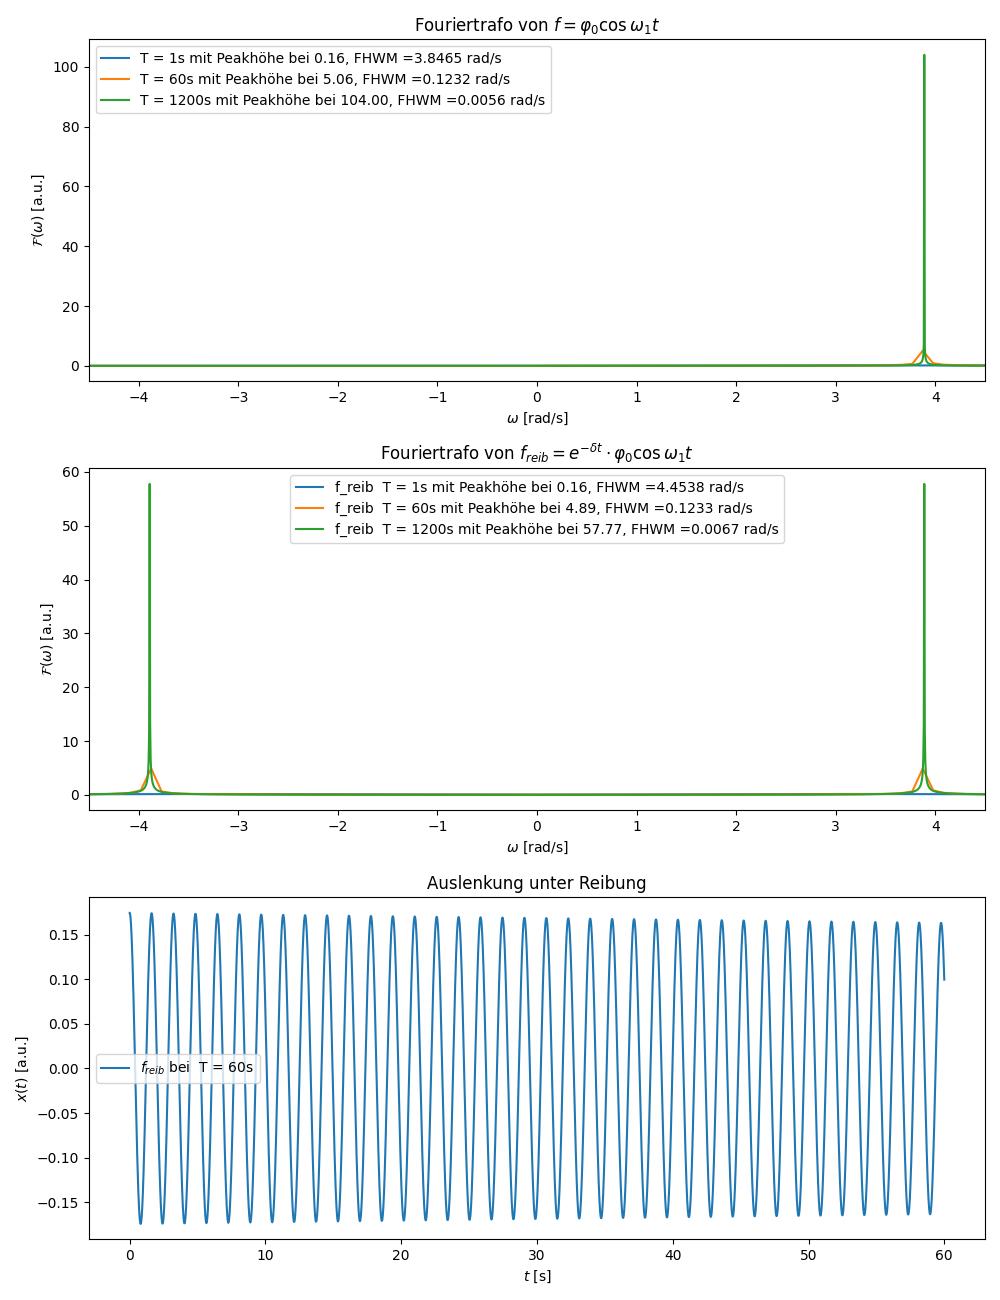

In [ ]:
import numpy as np
import matplotlib
'''
Definition der Größen der zu betrachtenden Einzelschwingung (symm./asymm.)
phi: Winkel phi_0. Die Zahl vor dem np.pi/180 ist in Grad. Der Extrafaktor␣
↪rechnet es in die SI-Einheit rad um.
a: omega_1 oder omega_2 in rad/s
T: Die insgesamte Messzeit. Hier könnt ihr ruhig etwas rumspielen und euch verschiedene Szenarien (z.B. ganz, ganz kurze Messzeit von 10s)
im Vergleich zu anderen (z.B. ganz, ganz lange Messzeit von 1200s) anschauen.
Dafür ist der Code gedacht!
'''

phi = 10 * np.pi/180 #Maximaler Auslenkwinkel (Startauslenkwinkel). Ist egal, bestimmt nur die Höhe der Amplitude am Ende!
a = 3.89
T = np.array([2,60,1200])
labels = np.array(['T = 1s', 'T = 60s', 'T = 1200s']) #labels, passend zu T, für Plots später
'''
Der folgende Abschnitt führt eine Rekursion durch. Für jede angegebene Messzeit␣
↪T wird die Amplitude der F-Transformierte berechnet.
F-Amplitude und zugehörige Winkelgeschwindigkeiten omega werden in Sammellisten␣
↪für spätere Plots zwischengespeichert.
'''
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, figsize=(10, 13))

F_shift_coll, omega_shift_coll = [], [] #Listen, in denen FFT Größen aus der For-Schleife (Iterationen für jede Zeit in T) gespeichert werden
FHWM=[]
F_shift_coll2, omega_shift_coll2 = [], [] #Listen, in denen FFT Größen aus der For-Schleife (Iterationen für jede Zeit in T) gespeichert werden
FHWM2=[]
peakamplitude1=[]
peakamplitude2=[]

for index,i in enumerate(T):
    T = i  #Aktuelle Messzeit (i) wird als Variable T gespeichert
    N = int(T/0.002) #Anzahl insgesamt gemessener Zeitschritte (2ms ist laut Skript die␣Abtast/Aufnahmerate)
    x = np.linspace(0, T, N, endpoint=False)
    f = phi * np.cos(a * x) #Funktion für symmetrische/asymmetrische Schwingung
    freib=np.exp(-0.0011*x)*f
    dx = x[1] - x[0]
    F = np.fft.fft(f) * dx #Fouriertransformierte der Zeitfunktion (Schwingung). Das dx ist notwendig, um von der diskreten Form in die kontinuierliche zu gehen
    omega = 2 * np.pi * np.fft.fftfreq(N, d=dx)     # erzeugt die x-Achsenwerte
    F_shift = np.fft.fftshift(F)  #Sortiert die Frequenzen von klein (minus) nach groß, da sie in F komisch sortiert sind 
    omega_shift = np.fft.fftshift(omega)
    omega_shift_coll.append(omega_shift)
    reellefreq = np.where(omega_shift > 0, np.abs(F_shift), 0) # Macht die linke Hälfte platt durch np.where(Bedingung, Wert_wenn_wahr, Wert_wenn_falsch)
    F_shift_coll.append(reellefreq)  #Fügt Ergebnisse in die Sammelliste ein
    peaks, xindex = find_peaks(reellefreq)       # spuckt Array aus Indexen (Stellen) des w-Arrays(x-Achse) aus, an denen ein Peak ist
    main_peak = peaks[np.argmax(reellefreq[peaks])]         # mit reellefreq[peaks] werden alle Amplituden der Indexstellen, die in [peaks] gespeichert sind, herausgeholt und sozusagen als phantom array gespeichert. davon wird mit np.argmax der Index des maximalsten Wertes aus diesem phantom array genommen. Und mit peaks[Index_maximaler_Wert] der mainpeak extrahiert. 
    print(omega_shift[main_peak])
    results = peak_widths(reellefreq, [main_peak], rel_height=0.5)
    FHWM.append(results[0][0]*2*np.pi*1/T)
    peakamplitude1.append(reellefreq[main_peak])

    F2 = np.fft.fft(freib) * dx #Fouriertransformierte der Zeitfunktion (Schwingung). Das dx ist notwendig, um von der diskreten Form in die kontinuierliche zu gehen
    omega2 = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    F_shift2 = np.fft.fftshift(F2)  #Sortiert die Frequenzen von klein (minus) nach groß
    omega_shift2 = np.fft.fftshift(omega2)
    F_shift_coll2.append(F_shift2)  #Fügt Ergebnisse in die Sammelliste ein
    omega_shift_coll2.append(omega_shift2)
    reellefreq2=np.abs(F_shift2)
    peaks2, _ = find_peaks(reellefreq2)
    main_peak2 = peaks2[np.argmax(reellefreq2[peaks2])]
    print(+omega_shift2[main_peak2])
    results2 = peak_widths(reellefreq2, [main_peak2], rel_height=0.5)
    FHWM2.append(results2[0][0]*2*np.pi*1/T)
    peakamplitude2.append(reellefreq2[main_peak2])

    if index==1:
        ax3.plot(x,freib, label = r'$f_{reib}$ bei  ' + labels[index])  #Plottet jedes Amplitudenspektrum (Amplitude der Fouriertransformierten) für jede Messzeit T in einen Plot
    # ax2.plot(x,f, label = labels[j]) 
    
''' 
Erstellung der Plots
'''
ax1.set_xlabel(r'$\omega$ [rad/s]')
ax1.set_ylabel(r'$\mathcal{F}(\omega)$ [a.u.]')
ax1.set_xlim(-4.5,4.5) #Interessanter Frequenzbereich (je nach Präferenz variabel)
ax1.set_title(r'Fouriertrafo von $f=\varphi_0\cos \omega_1t$')
for j in np.arange(0,len(F_shift_coll)):
    ax1.plot(omega_shift_coll[j], F_shift_coll[j], label = labels[j]+ f" mit Peakhöhe bei {peakamplitude1[j]:.2f}, FHWM ={FHWM[j]:.4f} rad/s")  #Plottet jedes Amplitudenspektrum (Amplitude der Fouriertransformierten) für jede Messzeit T in einen Plot
ax1.legend(loc = 'best')

ax2.set_xlabel(r'$\omega$ [rad/s]')
ax2.set_ylabel(r'$\mathcal{F}(\omega)$ [a.u.]')
ax2.set_xlim(-4.5,4.5) #Interessanter Frequenzbereich (je nach Präferenz variabel)
ax2.set_title(r'Fouriertrafo von $f_{reib}=e^{-\delta t} \cdot \varphi_0\cos \omega_1t$')
for j in np.arange(0,len(F_shift_coll)):
    ax2.plot(omega_shift_coll2[j], np.abs(F_shift_coll2[j]), label = r'f_reib  ' + labels[j]+ f" mit Peakhöhe bei {peakamplitude2[j]:.2f}, FHWM ={FHWM2[j]:.4f} rad/s")  #Plottet jedes Amplitudenspektrum (Amplitude der Fouriertransformierten) für jede Messzeit T in einen Plot
ax2.legend(loc = 'best')

ax3.set_xlabel(r'$t$ [s]')
ax3.set_ylabel(r'$x(t)$ [a.u.]')
# ax2.set_xlim(2,4.5) #Interessanter Frequenzbereich (je nach Präferenz variabel)
ax3.set_title(r'Auslenkung unter Reibung')
     
ax3.legend(loc = 'best')

plt.tight_layout()
plt.show()
# plt.savefig(Ausgabe_path/"Fouriertrafos.png",format="png")


In [11]:
# i looked up in the tx(t) file, that x(t=0)=92, x(t=58.13)=86
# so we can calculate delta out of these two points, we only need x(t=0) to calculate the scale of the a.u. units compared to the scale of cos(...)
scale=92/(phi*np.cos(a*0))
delta=-np.log(86/(scale*phi*np.cos(a*58.13)))/58.13
print(f"delta={delta}")
x_58=np.exp(-delta*58.13)*scale*phi*np.cos(a*58.13)
print(x_58) 

delta=0.0011192308478834433
86.0


LETS GO, passt also, dann haben sich die .tx(t) dateien doch gelohnt hah